In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  


In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from region import Region
pfns = PlottingFns()

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xeofs as xf
import xskillscore as xss
from cartopy.feature import LAND
from scipy.stats import pearsonr


In [4]:
elevation_ = GEBCO(coarsen_factor=40).ds.elevation

In [5]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

def seasonal_anomaly(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

def get_geostrophic_currents(eta):
    lat_name = 'latitude'
    lon_name = 'longitude'
    g = 9.81
    R = 6371000.0
    omega = 7.292115e-5

    # Ensure coords are present and in degrees
    lat = eta.coords[lat_name]
    lon = eta.coords[lon_name]

    # radians
    lat_r = np.deg2rad(lat)
    lon_r = np.deg2rad(lon)

    # Build helper to take gradients along given axes using the 1D radian coords
    # Works for data with optional leading dims (e.g., time)
    def d_dcoord(da: xr.DataArray, coord: xr.DataArray, axis: int) -> xr.DataArray:
        arr = da.data
        coord_vals = coord.data
        grad = np.gradient(arr, coord_vals, axis=axis, edge_order=2)
        return xr.zeros_like(da) + grad  # keep xarray wrapper/dims

    # Axis indices for lat/lon (support datasets with extra leading dims)
    lat_axis = eta.get_axis_num(lat_name)
    lon_axis = eta.get_axis_num(lon_name)

    # Partial derivatives wrt latitude/longitude in *radians*
    deta_dphi   = d_dcoord(eta, lat_r, lat_axis)         # ∂η/∂φ
    deta_dlambda= d_dcoord(eta, lon_r, lon_axis)         # ∂η/∂λ

    # Coriolis parameter f(φ)
    f = np.sin(lat_r) * omega * 2

    # Broadcast f and cosφ to data shape
    # (xarray auto-broadcasts by coords when wrapped in DataArray with dims)
    f_da = xr.DataArray(f, dims=(lat_name,), coords={lat_name: lat})
    cosphi = xr.DataArray(np.cos(lat_r), dims=(lat_name,), coords={lat_name: lat})

    # Geostrophic components
    ug = (1.0 / R) * deta_dphi * -(g / f_da) 
    vg = (1.0 / (R * cosphi)) * deta_dlambda * (g / f_da)

    ug.name = "ug"; ug.attrs.update(units="m s-1", long_name="zonal geostrophic velocity")
    vg.name = "vg"; vg.attrs.update(units="m s-1", long_name="meridional geostrophic velocity")

    return ug, vg


In [6]:
sla_ = SLA(deg=0.25).da
winds_ = xr.open_dataset('ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})
sam = Index(type='SAM').da.sel(time=slice(sla_.time[0],sla_.time[-1]))
dotds = DOT().ds.rename({'ug':'u10','vg':'v10'})

In [7]:
extent_ac = [138,152,-68,-63]
extent_gyre = [145,149,-66.5,-65.5]
extent_ea = [60,160,-70,-60]
extent_mi = [20,180,-74,-50]

elevation = elevation_.sel(latitude = slice(extent_ea[2], extent_ea[3]), longitude = slice(extent_ea[0],extent_ea[1]))

In [8]:
da_sla = seasonal_anomaly(Region('Adelie',extent_ac,elevation=elevation).crop_da(sla_).interpolate_na(dim='time'))
da_sla = Region('Adelie',extent_ac,elevation=elevation).crop_da(sla_).interpolate_na(dim='time')

In [9]:
pca = xf.single.EOF(n_modes=3, standardize=True, use_coslat=True)
pca.fit(da_sla, dim="time")
components = pca.components()
scores = pca.scores()
evr=pca.explained_variance_ratio()


/nfs/b0133/eejco/miniconda3/envs/sha-env/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1614: UserWarning: The following kwargs were not used by contour: 'linestyle', 'c'
  result = super().contour(*args, **kwargs)


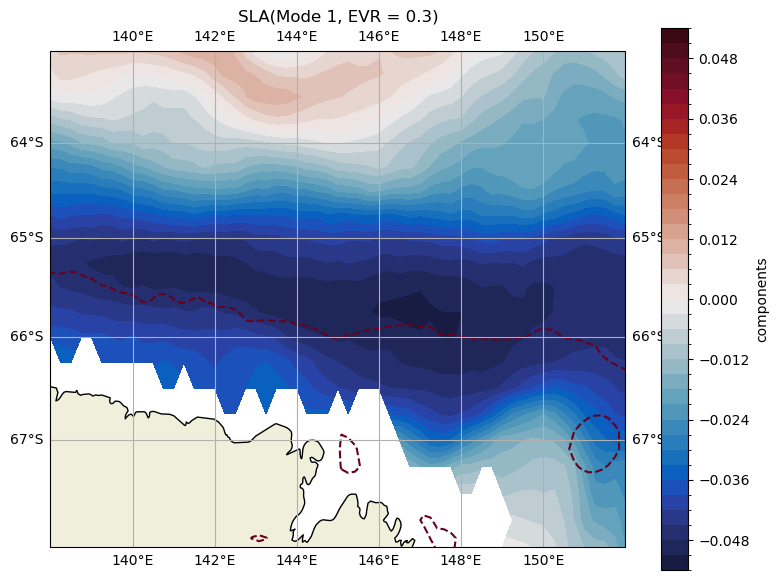

In [10]:
fig,ax = plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.Mercator()})

# plot maps
mode=1
comp=-components.sel(mode=mode)
evr_=evr.sel(mode=mode).item()
comp.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40)
ax.set_extent(extent_ac,crs=ccrs.PlateCarree())
ax.add_feature(LAND, edgecolor='k')
ax.gridlines(draw_labels=True)
elevation.plot.contour(x='longitude',y='latitude',ax=ax,transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')
ax.set_title('SLA' + '(Mode {0}, EVR = {1})'.format(mode,round(evr_,2)))


plt.tight_layout()

In [11]:
scores.attrs.clear()
gi = -scores.sel(mode=1)
gi.to_netcdf('gyre_index.nc')

<GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

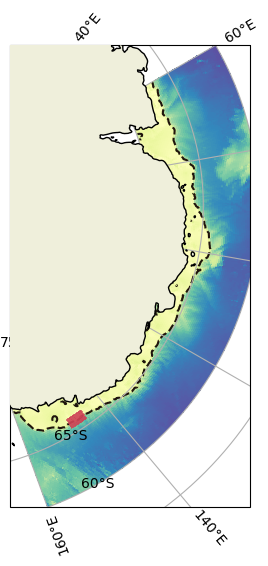

In [12]:
# show study area and gyre area
region_ac = Region('AC',extent_ac)
region_gyre = Region('Gyre',extent_gyre,elevation=elevation)
region_gyre.plot_region(da=elevation,extent=extent_ea)

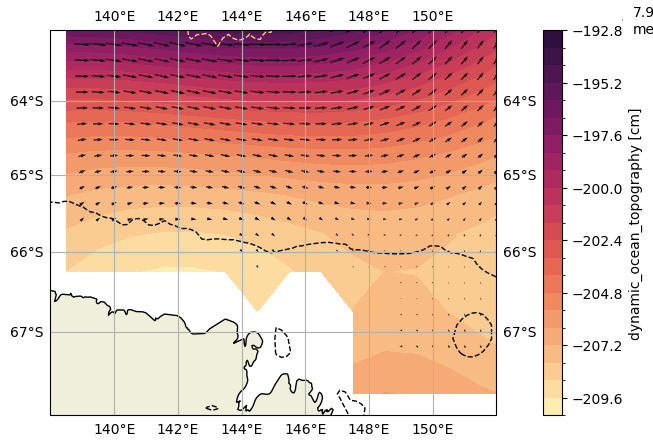

In [13]:
# show mdt an mean geostrophic currents
dot = region_ac.crop_da(dotds)
mdt = dot.mean('time')

fig,ax = plt.subplots(figsize=(12,5),subplot_kw={'projection':ccrs.Mercator()})
mdt.dot.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.matter,transform=ccrs.PlateCarree(),levels=25)
mdt.plot.quiver(ax=ax,x='longitude',y='latitude',u='u10', v='v10',transform=ccrs.PlateCarree(),regrid_shape=25)

elevation.plot.contour(x='longitude',y='latitude',ax=ax,levels=[-1000,-4000],transform=ccrs.PlateCarree(),cmap="copper_r",vmin=-10000,vmax=0,linewidths=1,linestyles='--')

ax.set_extent(extent_ac,crs=ccrs.PlateCarree())
ax.add_feature(LAND, edgecolor='k')
ax.gridlines(draw_labels=True)

In [14]:
region = Region('Adelie',extent_ac,elevation=elevation)#,min_elevation=-1000)
sla = region.crop_da(sla_)
#sice = region.crop_da(sice_)
winds = region.crop_da(winds_)

# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

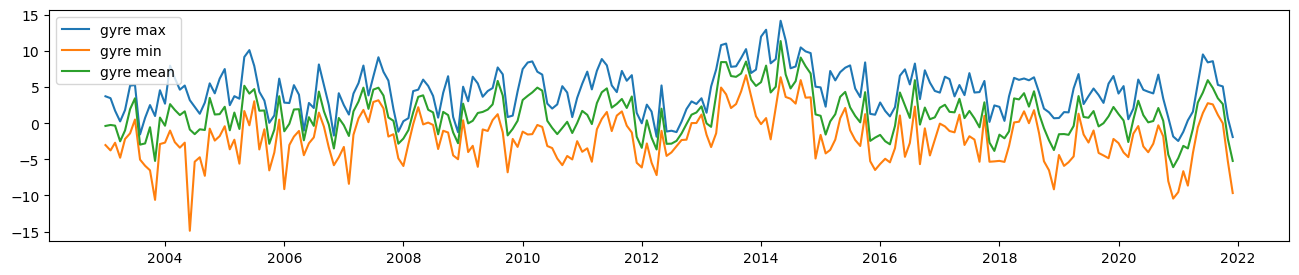

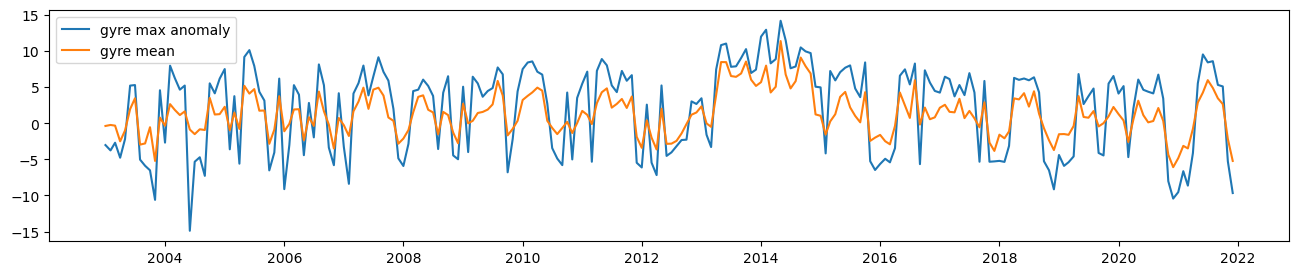

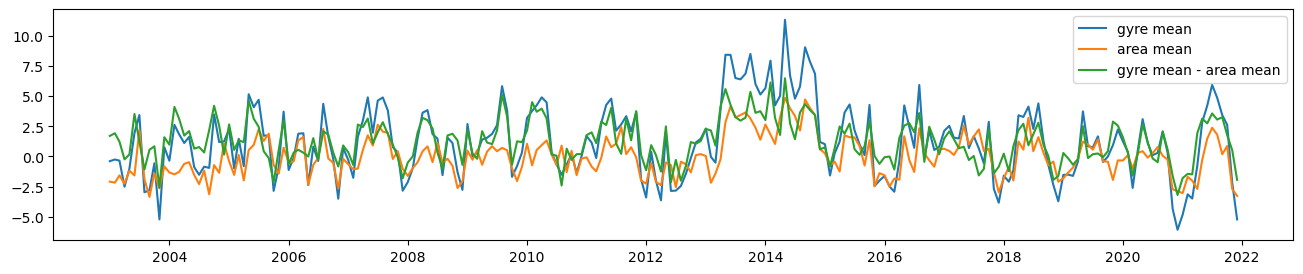

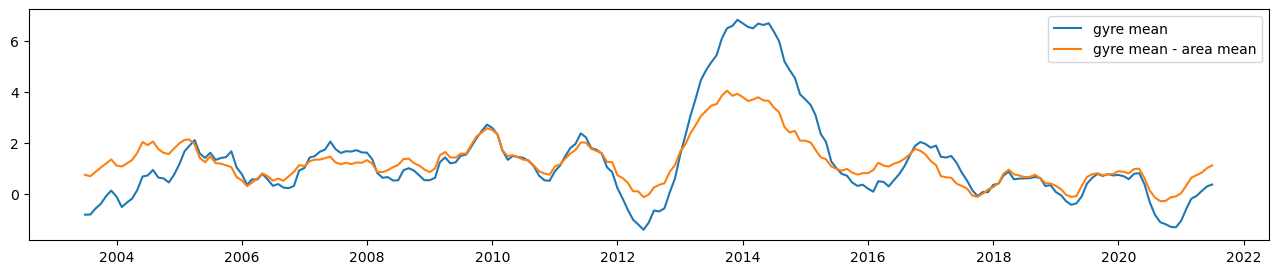

In [15]:
sla_gyre = region_gyre.crop_da(sla_)

ll = ['latitude','longitude']
ghmax = sla_gyre.max(ll)
ghmin = sla_gyre.min(ll)
ghmean = sla_gyre.mean(ll)

gyre_max_anom = [gh.max(ll) if gh.mean(ll) > 0 else gh.min(ll) for gh in sla_gyre]
gyre_index = ghmean - sla.mean(ll)

# compare different gyre indices
fig,ax = plt.subplots(figsize=(16,3))
ax.plot(sla_gyre.time,ghmax,label='gyre max')
ax.plot(sla_gyre.time,ghmin,label='gyre min')
ax.plot(sla_gyre.time,ghmean,label='gyre mean')
ax.legend()

# compare different gyre indices
fig,ax = plt.subplots(figsize=(16,3))
ax.plot(sla_gyre.time,gyre_max_anom,label='gyre max anomaly')
ax.plot(sla_gyre.time,ghmean,label='gyre mean')
ax.legend()

# compare different gyre indices
fig,ax = plt.subplots(figsize=(16,3))
ax.plot(sla_gyre.time,ghmean,label='gyre mean')
ax.plot(sla.time,sla.mean(ll),label='area mean')
ax.plot(sla_gyre.time,gyre_index,label='gyre mean - area mean')
ax.legend()

fig,ax = plt.subplots(figsize=(16,3))


# compare with ASC
ax.plot(sla_gyre.time,ghmean.rolling({'time':12},center=True).mean(),label='gyre mean')
ax.plot(sla_gyre.time,gyre_index.rolling({'time':12},center=True).mean(),label='gyre mean - area mean')

#compute asc strength
asc=dotds.u10.sel(latitude=slice(-65,-64)).sel(longitude=145,method='nearest').mean('latitude')
#ax.twinx().plot(asc.time,asc.rolling({'time':12},center=True).mean(),c='k')

ax.legend()

In [16]:
#plos min and maxes
# fig,ax = plt.subplots(1,2,figsize=(16,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
# t=pd.Timestamp(2014,1,1)
# plotc(ax[0],sla.sel(time=t),'max ={}, min={}'.format(ghmax.sel(time=t).item(),ghmin.sel(time=t).item()),extent,cmap=cmocean.cm.balance)
#plotc(ax[1],season_split(sice)['winter'].mean('time'),'SIC WINTER',extent,vmin=0.4,vmax=1,cmap=cmocean.cm.ice)

Rendering..


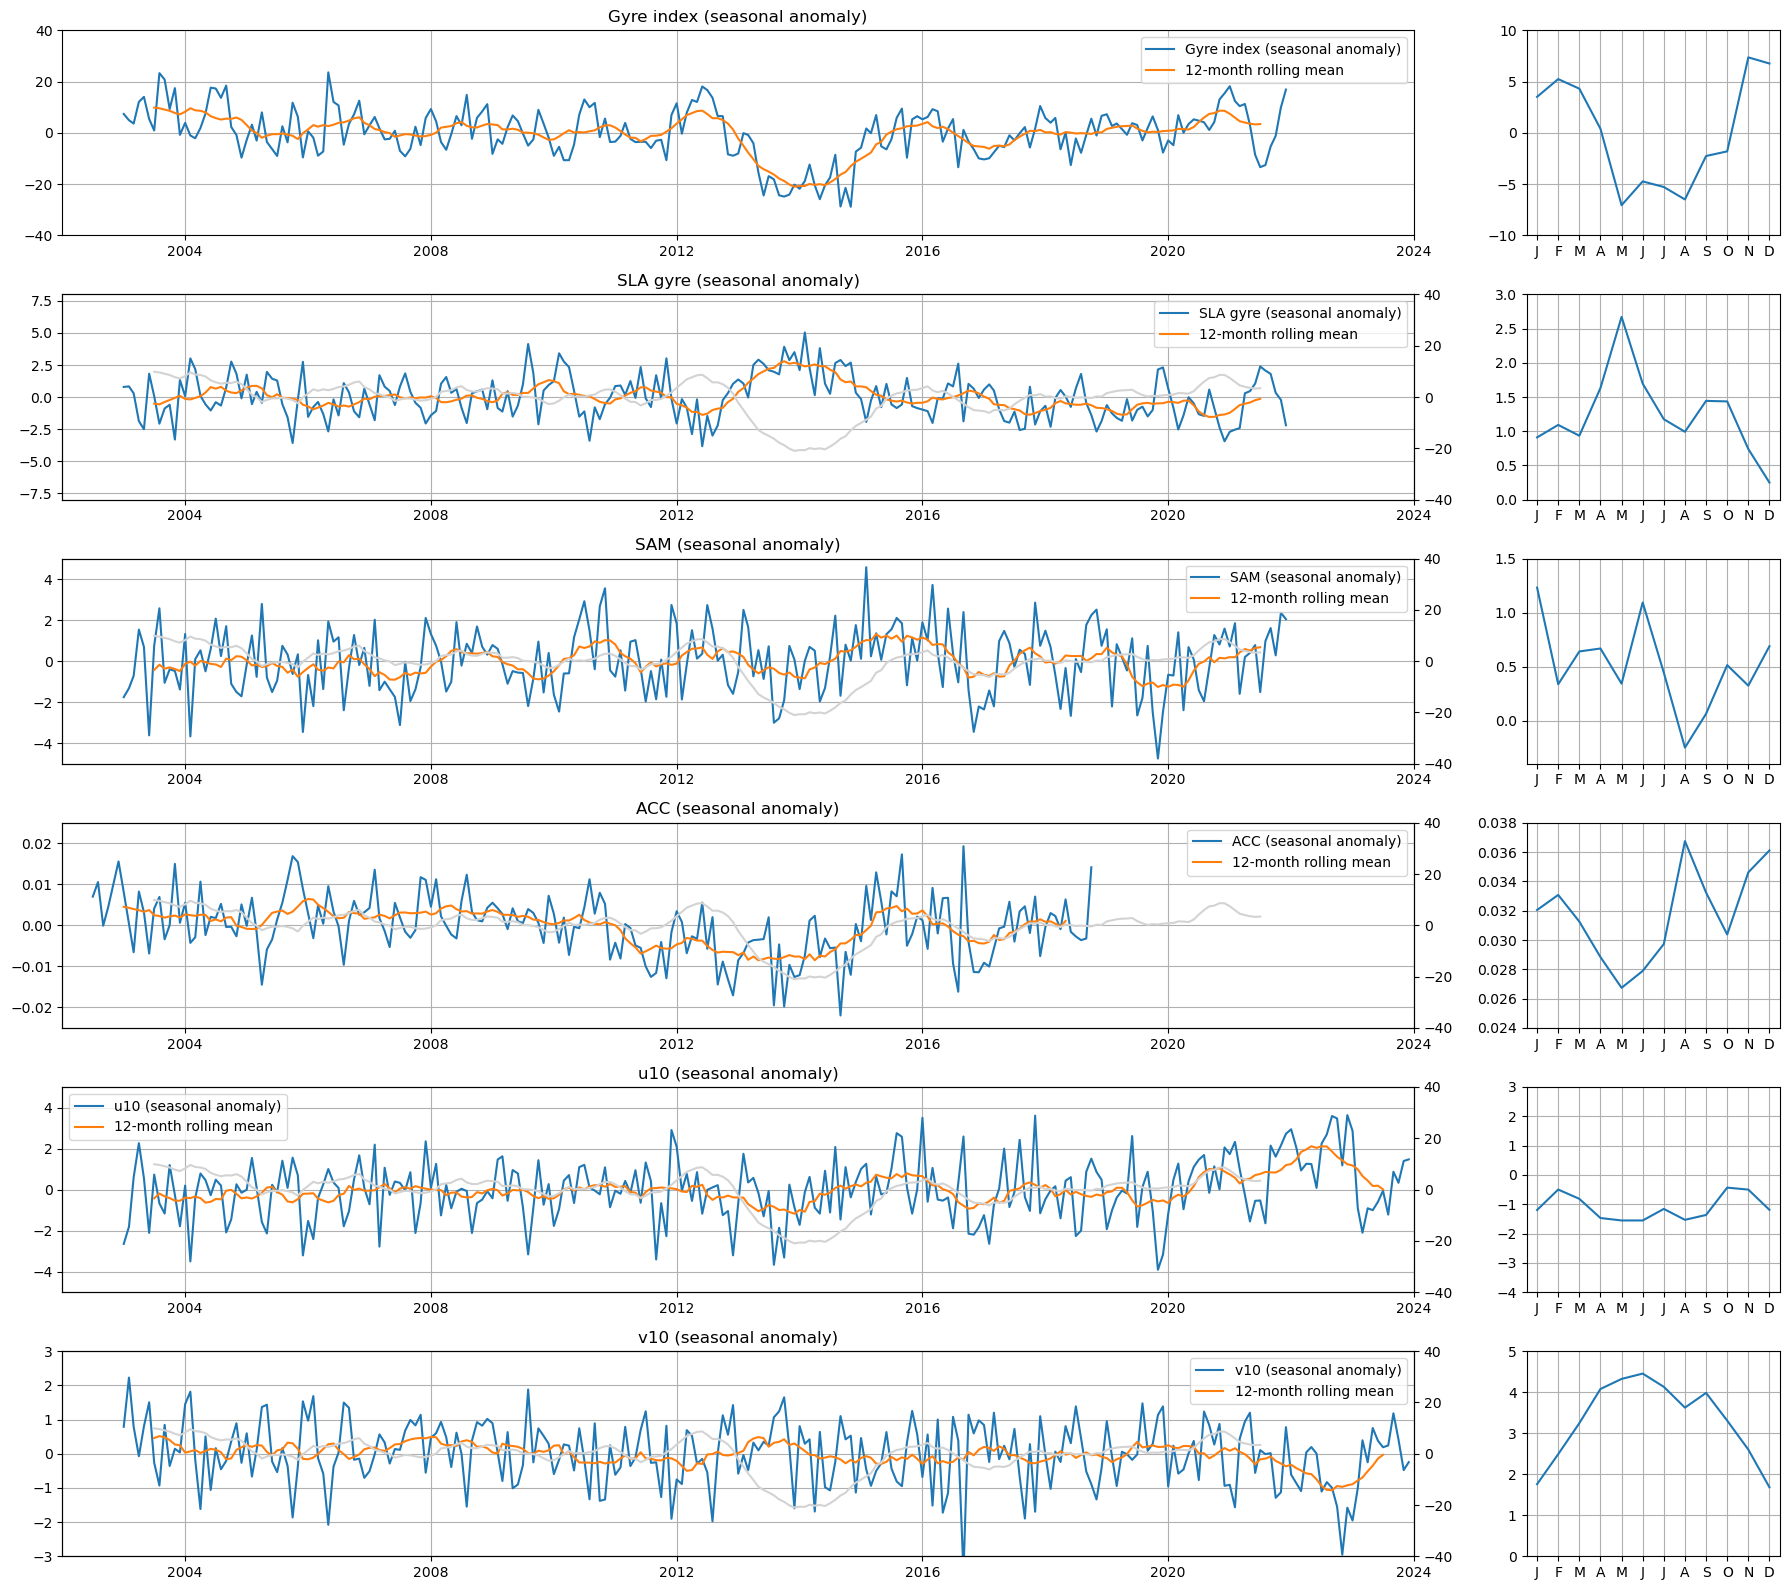

In [17]:
fig = plt.figure(figsize=(18,16))
axs=[]

gs = fig.add_gridspec(6,5)

def add_row(n,var,varname,ylim=[-16,16],ylim_cmt=[-7,7],anom=False):

    axs.append(fig.add_subplot(gs[n,0:4]))
    axs.append(fig.add_subplot(gs[n,4:6]))

    if 'latitude' in var.dims:
        da = var.mean(['latitude','longitude'])
    else:
        da = var
        
    cmt = da.groupby('time.month').mean()

    ax = axs[(n*2)]

    if anom:
        da = da.groupby('time.month') - cmt
        varname = varname + ' (seasonal anomaly)'

    ax.plot(da.time,da,label=varname)
    ax.plot(da.time,da.rolling(time=12,center=True).mean(),label='12-month rolling mean')

    ax.set_title(varname)
    ax.legend(loc='best')
    ax.set_ylim(ylim)
    ax.set_xlim([pd.Timestamp(2002,1,1),pd.Timestamp(2024,1,1)])
    ax.grid()

    ax = axs[(n*2)+1]

    ax.plot(cmt.month,cmt)
    ax.set_ylim(ylim_cmt)
    ax.grid()
    ax.set_xticks(cmt.month,labels=['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])

add_row(0,gi,'Gyre index',anom=True,ylim=[-40,40],ylim_cmt=[-10,10])
add_row(1,gyre_index,'SLA gyre',anom=True,ylim=[-8,8],ylim_cmt=[0,3])
add_row(2,sam,'SAM',anom=True,ylim=[-5,5],ylim_cmt=[-0.4,1.5])
add_row(3,asc,'ACC',anom=True,ylim=[-0.025,0.025],ylim_cmt=[0.024,0.038])
add_row(4,winds.u10,'u10',anom=True,ylim=[-5,5],ylim_cmt=[-4,3])
add_row(5,winds.v10,'v10',anom=True,ylim=[-3,3],ylim_cmt=[0,5])

for axs in [axs[2],axs[4],axs[6],axs[8],axs[10]]:
    tx = axs.twinx()
    tx.plot(gi.time,gi.rolling(time=12,center=True).mean(),c='lightgrey')
    tx.set_ylim([-40,40])



plt.tight_layout()
print('Rendering..')


In [18]:
xr.align(v,w)[1]

NameError: name 'v' is not defined

In [ ]:
vars = [gi,gyre_index,sam,asc]
cmat = np.empty((len(vars),len(vars)))
pmat = np.empty((len(vars),len(vars)))

# vars = []

# for v in vars_:
#     cmt = v.groupby('time.month').mean()
#     var = (v-cmt).rolling({'time':12},center=True).mean()
#     vars.append(var)
ts = gi.time[0]

for i,v in enumerate(vars):
    for j,w in enumerate(vars):
        vw, wv = xr.align(v,w)
        cmat[i][j] = xr.corr(vw,wv).item()
        pmat[i][j] = pearsonr(vw, wv)[1]

In [ ]:
matt = pd.DataFrame(cmat,columns=['GI','SLA','SAM','ASC'],index=['GI','SLA','SAM','ASC'])

In [ ]:
pmat

array([[0.00000000e+00, 2.16450002e-33, 5.14170637e-09, 1.06771734e-12],
       [2.16450002e-33, 0.00000000e+00, 5.00786034e-10, 2.02525375e-16],
       [5.14170637e-09, 5.00786034e-10, 0.00000000e+00, 3.84309752e-06],
       [1.06771734e-12, 2.02525375e-16, 3.84309752e-06, 0.00000000e+00]])

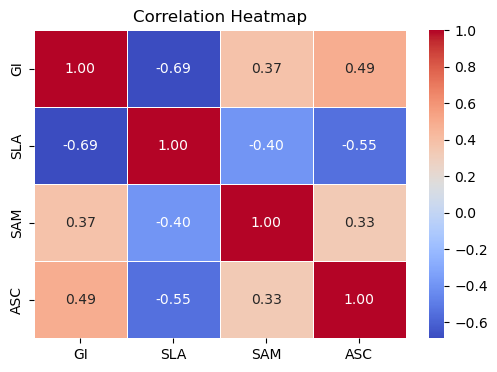

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(matt, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()